In [1]:
import os
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

In [3]:
# Essential libraries
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import spearmanr, skew
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from catboost import CatBoostRegressor
import torch

In [4]:
# Set random seed for reproducibility
seed = 69
torch.manual_seed(seed)
np.random.seed(seed)

In [5]:
# Define root directory
root = '.'

In [7]:
# Load dataset
(samples, siss, ohss, okss, participants) = torch.load(os.path.join(root, 'dataset/dataset-' + 'daily' + '.pt'), weights_only = False)

In [8]:
# Display unique participants and their counts
unique_values, counts = np.unique(participants, return_counts=True)
print(unique_values)
print(counts)

[ 1  2  3  4  5  6  7  8  9 10]
[59 58 58 57 57 56 57 58 58 56]


In [9]:
# Initialize variables
x = samples
y = siss
p = participants

In [10]:
Y_TRUES = np.empty([0])
Y_PREDS = np.empty([0])

In [12]:
Y_PREDS

array([], dtype=float64)

In [16]:
np.array([])

array([], dtype=float64)

In [19]:
x.shape[0]

574

In [22]:
# Perform cross-validation
cv = KFold(n_splits=x.shape[0], shuffle=True, random_state=seed)   ### 574 fold, cioè 574 cross-valid con 1 record di test solo

for fold, (train_idx, test_idx) in enumerate(cv.split(x), start=1):
    
    participant = np.unique(p[test_idx])[0]

    x_train, x_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(participant, x_train.shape[0], x_test.shape[0])
    
    # Standardize features
    scaler = StandardScaler()             #### https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
    scaler.fit(x_train)                   #### quella che in statistica è la normalizzazione (Teorema del Limite Centrale)
    x_train = scaler.transform(x_train)   #### diventa una Normale(0,1)
    x_test = scaler.transform(x_test)
    
    # Normalize features
    normalizer = MinMaxScaler()          #### una volta normalizzata, porto tutto nell'intervallo [0, 1]
    normalizer.fit(x_train)
    x_train = normalizer.transform(x_train)
    x_test = normalizer.transform(x_test)
    
    # Train model (CatBoostRegressor)
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=.1,
        depth=3,
        loss_function='RMSE',
        verbose=10000
    )
    
    model.fit(
        x_train, y_train,
        eval_set=(x_test, y_test),
        use_best_model=True,
        early_stopping_rounds=100
    )
    y_preds = model.predict(x_test)

    # Append results
    Y_TRUES = np.append(Y_TRUES, y_test)
    Y_PREDS = np.append(Y_PREDS, y_preds)

6 573 1
0:	learn: 3.1736496	test: 0.7020562	best: 0.7020562 (0)	total: 212ms	remaining: 3m 32s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.00108031652
bestIteration = 22

Shrink model to first 23 iterations.
1 573 1
0:	learn: 3.1712162	test: 1.7723504	best: 1.7723504 (0)	total: 4.26ms	remaining: 4.26s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6282161264
bestIteration = 214

Shrink model to first 215 iterations.
1 573 1
0:	learn: 3.1710295	test: 1.2777145	best: 1.2777145 (0)	total: 3.81ms	remaining: 3.81s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.104984204
bestIteration = 14

Shrink model to first 15 iterations.
7 573 1
0:	learn: 3.1739904	test: 0.7747503	best: 0.7747503 (0)	total: 3.44ms	remaining: 3.43s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.2957797184
bestIteration = 12

Shrink model to first 13 iterations.
9 573 1
0:	learn: 3.1689587	test: 4.3070823	best: 4.3070823 (0)	total:

Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.003291923736
bestIteration = 13

Shrink model to first 14 iterations.
5 573 1
0:	learn: 3.1659353	test: 5.7200475	best: 5.7200475 (0)	total: 4.41ms	remaining: 4.4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 2.273581569
bestIteration = 202

Shrink model to first 203 iterations.
10 573 1
0:	learn: 3.1693549	test: 4.3048684	best: 4.3048684 (0)	total: 3.23ms	remaining: 3.23s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 4.104106143
bestIteration = 3

Shrink model to first 4 iterations.
10 573 1
0:	learn: 3.1693549	test: 4.3048684	best: 4.3048684 (0)	total: 2.67ms	remaining: 2.66s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 4.104106143
bestIteration = 3

Shrink model to first 4 iterations.
10 573 1
0:	learn: 3.1736065	test: 1.9596947	best: 1.9596947 (0)	total: 3.8ms	remaining: 3.79s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.16650

Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.00162825853
bestIteration = 92

Shrink model to first 93 iterations.
3 573 1
0:	learn: 3.1740374	test: 0.7020562	best: 0.7020562 (0)	total: 3.04ms	remaining: 3.04s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.0005023299198
bestIteration = 143

Shrink model to first 144 iterations.
1 573 1
0:	learn: 3.1737723	test: 1.2847613	best: 1.2847613 (0)	total: 3.54ms	remaining: 3.53s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4777279286
bestIteration = 77

Shrink model to first 78 iterations.
4 573 1
0:	learn: 3.1723359	test: 2.6355633	best: 2.6355633 (0)	total: 3.05ms	remaining: 3.04s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.05805063322
bestIteration = 650

Shrink model to first 651 iterations.
9 573 1
0:	learn: 3.1705221	test: 4.0010376	best: 4.0010376 (0)	total: 3.04ms	remaining: 3.04s
Stopped by overfitting detector  (100 iterations wait)

bestTes

0:	learn: 3.1734252	test: 1.7046527	best: 1.7046527 (0)	total: 2.93ms	remaining: 2.93s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.2579142603
bestIteration = 103

Shrink model to first 104 iterations.
5 573 1
0:	learn: 3.1685960	test: 4.7214937	best: 4.7214937 (0)	total: 2.68ms	remaining: 2.68s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.00128096643
bestIteration = 186

Shrink model to first 187 iterations.
8 573 1
0:	learn: 3.1744632	test: 0.2931519	best: 0.2931519 (0)	total: 4.22ms	remaining: 4.22s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.01012277399
bestIteration = 18

Shrink model to first 19 iterations.
1 573 1
0:	learn: 3.1733017	test: 1.7779423	best: 1.7779423 (0)	total: 2.83ms	remaining: 2.82s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.614202679
bestIteration = 6

Shrink model to first 7 iterations.
2 573 1
0:	learn: 3.1655379	test: 5.3205094	best: 5.3205094 (0)	total: 4.26ms

Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.01192081382
bestIteration = 0

Shrink model to first 1 iterations.
9 573 1
0:	learn: 3.1739285	test: 1.7085599	best: 1.7085599 (0)	total: 3.63ms	remaining: 3.62s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.3274942433
bestIteration = 78

Shrink model to first 79 iterations.
6 573 1
0:	learn: 3.1722375	test: 2.7727833	best: 2.7727833 (0)	total: 3.38ms	remaining: 3.38s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.01100304168
bestIteration = 155

Shrink model to first 156 iterations.
9 573 1
0:	learn: 3.1731812	test: 2.0142998	best: 2.0142998 (0)	total: 3.93ms	remaining: 3.93s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6461180106
bestIteration = 578

Shrink model to first 579 iterations.
5 573 1
0:	learn: 3.1682881	test: 4.7095582	best: 4.7095582 (0)	total: 3.22ms	remaining: 3.22s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1

...

Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.2742377448
bestIteration = 434

Shrink model to first 435 iterations.
5 573 1
0:	learn: 3.1687383	test: 4.7214937	best: 4.7214937 (0)	total: 8.34ms	remaining: 8.33s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.587153384
bestIteration = 732

Shrink model to first 733 iterations.
8 573 1
0:	learn: 3.1612121	test: 7.0092789	best: 7.0092789 (0)	total: 3.42ms	remaining: 3.42s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 4.682640625
bestIteration = 69

Shrink model to first 70 iterations.
5 573 1
0:	learn: 3.1658817	test: 4.6424502	best: 4.6424502 (0)	total: 3.89ms	remaining: 3.89s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 2.080065264
bestIteration = 76

Shrink model to first 77 iterations.
7 573 1
0:	learn: 3.1673425	test: 4.9656868	best: 4.9656868 (0)	total: 2.86ms	remaining: 2.86s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 4.33

0:	learn: 3.1655949	test: 5.3828723	best: 5.3828723 (0)	total: 3.25ms	remaining: 3.24s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 4.488535605
bestIteration = 138

Shrink model to first 139 iterations.
7 573 1
0:	learn: 3.1712957	test: 1.0673841	best: 1.0673841 (0)	total: 4.26ms	remaining: 4.25s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.067384142
bestIteration = 0

Shrink model to first 1 iterations.
10 573 1
0:	learn: 3.1736065	test: 1.9596947	best: 1.9596947 (0)	total: 3.43ms	remaining: 3.42s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.00708651118
bestIteration = 44

Shrink model to first 45 iterations.
2 573 1
0:	learn: 3.1732545	test: 1.3736545	best: 1.3736545 (0)	total: 3.29ms	remaining: 3.29s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.373654517
bestIteration = 0

Shrink model to first 1 iterations.
2 573 1
0:	learn: 3.1652937	test: 5.3125880	best: 5.3125880 (0)	total: 3.66ms	remai

Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6005899541
bestIteration = 1

Shrink model to first 2 iterations.
8 573 1
0:	learn: 3.1745021	test: 0.0091873	best: 0.0091873 (0)	total: 2.93ms	remaining: 2.93s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.00918731623
bestIteration = 0

Shrink model to first 1 iterations.
6 573 1
0:	learn: 3.1741496	test: 0.7688520	best: 0.7688520 (0)	total: 3.25ms	remaining: 3.25s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.01041603146
bestIteration = 44

Shrink model to first 45 iterations.
9 573 1
0:	learn: 3.1705195	test: 3.9983829	best: 3.9983829 (0)	total: 2.98ms	remaining: 2.98s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 2.228634893
bestIteration = 66

Shrink model to first 67 iterations.
6 573 1
0:	learn: 3.1720602	test: 2.7811343	best: 2.7811343 (0)	total: 3.7ms	remaining: 3.69s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9090065

0:	learn: 3.1715647	test: 2.7787394	best: 2.7787394 (0)	total: 3.97ms	remaining: 3.96s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5030167134
bestIteration = 644

Shrink model to first 645 iterations.
8 573 1
0:	learn: 3.1611714	test: 7.0092789	best: 7.0092789 (0)	total: 3.23ms	remaining: 3.22s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 4.827127737
bestIteration = 160

Shrink model to first 161 iterations.
6 573 1
0:	learn: 3.1717413	test: 0.0655775	best: 0.0655775 (0)	total: 3.73ms	remaining: 3.72s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.000356970958
bestIteration = 44

Shrink model to first 45 iterations.
5 573 1
0:	learn: 3.1686510	test: 4.6401722	best: 4.6401722 (0)	total: 3.86ms	remaining: 3.86s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 2.076676492
bestIteration = 263

Shrink model to first 264 iterations.
4 573 1
0:	learn: 3.1739548	test: 1.6332588	best: 1.6332588 (0)	total: 2.8

Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.801453964
bestIteration = 13

Shrink model to first 14 iterations.
1 573 1
0:	learn: 3.1733017	test: 1.7779423	best: 1.7779423 (0)	total: 3.83ms	remaining: 3.83s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5559780737
bestIteration = 60

Shrink model to first 61 iterations.
5 573 1
0:	learn: 3.1657499	test: 5.6424766	best: 5.6424766 (0)	total: 3.25ms	remaining: 3.24s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7155048231
bestIteration = 514

Shrink model to first 515 iterations.
10 573 1
0:	learn: 3.1678218	test: 4.9453985	best: 4.9453985 (0)	total: 4.47ms	remaining: 4.46s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.802644135
bestIteration = 195

Shrink model to first 196 iterations.
8 573 1
0:	learn: 3.1740917	test: 0.3054756	best: 0.3054756 (0)	total: 4.72ms	remaining: 4.71s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.

In [23]:
# Sort results for plotting
indx = Y_TRUES.argsort()
Y_TRUES = Y_TRUES[indx]
Y_PREDS = Y_PREDS[indx]

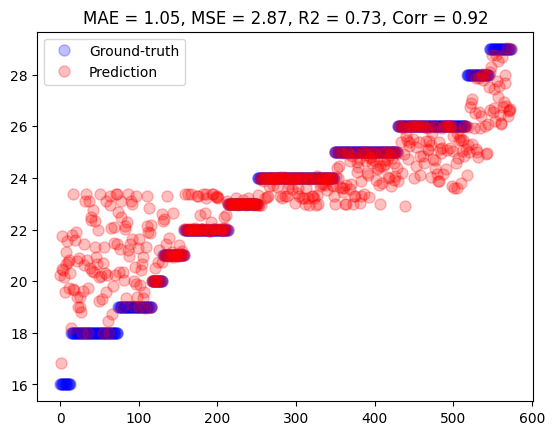

In [24]:
# Plot results
plt.figure()
plt.plot(Y_TRUES, 'o', color='blue', alpha=.25, markersize=8, label='Ground-truth')
plt.plot(Y_PREDS, 'o', color='red', alpha=.25, markersize=8, label='Prediction')
plt.title('MAE = ' + str(mean_absolute_error(Y_TRUES, Y_PREDS).__round__(2)) +
          ', MSE = ' + str(mean_squared_error(Y_TRUES, Y_PREDS).__round__(2)) +
          ', R2 = ' + str(r2_score(Y_TRUES, Y_PREDS).__round__(2)) +
          ', Corr = ' + str(spearmanr(Y_TRUES, Y_PREDS)[0].__round__(2)))
plt.legend()
plt.show()

In [25]:
# Print performance metrics
print('MAE = ' + str(mean_absolute_error(Y_TRUES, Y_PREDS).__round__(2)) +
      ', MSE = ' + str(mean_squared_error(Y_TRUES, Y_PREDS).__round__(2)) +
      ', R2 = ' + str(r2_score(Y_TRUES, Y_PREDS).__round__(2)) +
      ', Corr = ' + str(spearmanr(Y_TRUES, Y_PREDS)[0].__round__(2)))

MAE = 1.05, MSE = 2.87, R2 = 0.73, Corr = 0.92
